In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import confusion_matrix


In [6]:

data=pd.read_csv("/content/startup data.csv")
data

,Unnamed: 0,state_code,latitude,longitude,zip_code,id,city,Unnamed: 6,name,labels,...,object_id,has_VC,has_angel,has_roundA,has_roundB,has_roundC,has_roundD,avg_participants,is_top500,status
0,1005,CA,42.358880,-71.056820,92101,c:6669,San Diego,NaN,Bandsintown,1,...,c:6669,0,1,0,0,0,0,1.0000,0,acquired
1,204,CA,37.238916,-121.973718,95032,c:16283,Los Gatos,NaN,TriCipher,1,...,c:16283,1,0,0,1,1,1,4.7500,1,acquired
2,1001,CA,32.901049,-117.192656,92121,c:65620,San Diego,San Diego CA 92121,Plixi,1,...,c:65620,0,0,1,0,0,0,4.0000,1,acquired
3,738,CA,37.320309,-122.050040,95014,c:42668,Cupertino,Cupertino CA 95014,Solidcore Systems,1,...,c:42668,0,0,0,1,1,1,3.3333,1,acquired
4,1002,CA,37.779281,-122.419236,94105,c:65806,San Francisco,San Francisco CA 94105,Inhale Digital,0,...,c:65806,1,1,0,0,0,0,1.0000,1,closed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
918,352,CA,37.740594,-122.376471,94107,c:21343,San Francisco,NaN,CoTweet,1,...,c:21343,0,0,1,0,0,0,6.0000,1,acquired
919,721,MA,42.504817,-71.195611,1803,c:41747,Burlington,Burlington MA 1803,Reef Point Systems,0,...,c:41747,1,0,0,1,0,0,2.6667,1,closed
920,557,CA,37.408261,-122.015920,94089,c:31549,Sunnyvale,NaN,Paracor Medical,0,...,c:31549,0,0,0,0,0,1,8.0000,1,closed
921,589,CA,37.556732,-122.288378,94404,c:33198,San Francisco,NaN,Causata,1,...,c:33198,0,0,1,1,0,0,1.0000,1,acquired


In [ ]:

df=pd.read_csv("/content/startup data.csv")
df.head()

,Unnamed: 0,state_code,latitude,longitude,zip_code,id,city,Unnamed: 6,name,labels,...,object_id,has_VC,has_angel,has_roundA,has_roundB,has_roundC,has_roundD,avg_participants,is_top500,status
0,1005,CA,42.358880,-71.056820,92101,c:6669,San Diego,NaN,Bandsintown,1,...,c:6669,0,1,0,0,0,0,1.0000,0,acquired
1,204,CA,37.238916,-121.973718,95032,c:16283,Los Gatos,NaN,TriCipher,1,...,c:16283,1,0,0,1,1,1,4.7500,1,acquired
2,1001,CA,32.901049,-117.192656,92121,c:65620,San Diego,San Diego CA 92121,Plixi,1,...,c:65620,0,0,1,0,0,0,4.0000,1,acquired
3,738,CA,37.320309,-122.050040,95014,c:42668,Cupertino,Cupertino CA 95014,Solidcore Systems,1,...,c:42668,0,0,0,1,1,1,3.3333,1,acquired
4,1002,CA,37.779281,-122.419236,94105,c:65806,San Francisco,San Francisco CA 94105,Inhale Digital,0,...,c:65806,1,1,0,0,0,0,1.0000,1,closed


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 923 entries, 0 to 922
Data columns (total 49 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                923 non-null    int64  
 1   state_code                923 non-null    object 
 2   latitude                  923 non-null    float64
 3   longitude                 923 non-null    float64
 4   zip_code                  923 non-null    object 
 5   id                        923 non-null    object 
 6   city                      923 non-null    object 
 7   Unnamed: 6                430 non-null    object 
 8   name                      923 non-null    object 
 9   labels                    923 non-null    int64  
 10  founded_at                923 non-null    object 
 11  closed_at                 335 non-null    object 
 12  first_funding_at          923 non-null    object 
 13  last_funding_at           923 non-null    object 
 14  age_first_

In [ ]:
# EDA Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10,6)


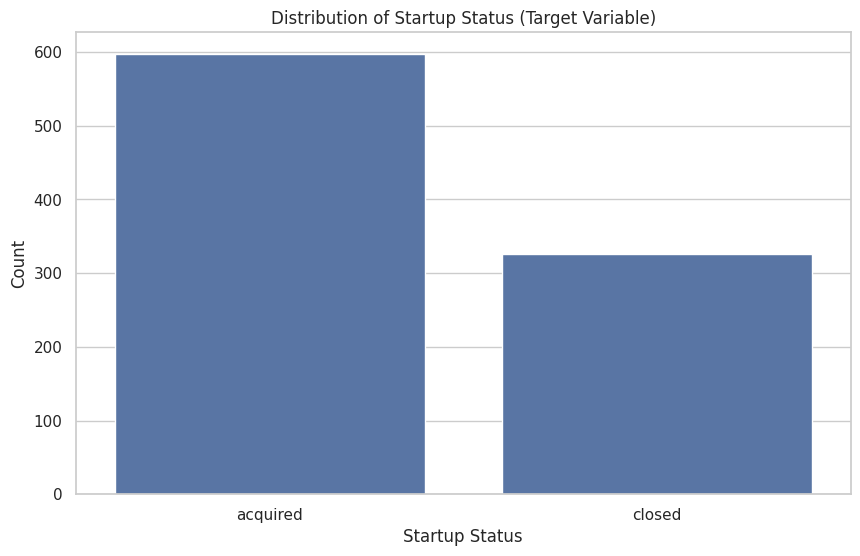

status
acquired    64.68039
closed      35.31961
Name: proportion, dtype: float64


In [7]:
df=pd.read_csv("/content/startup data.csv")

# Class Distribution Plot
plt.figure()
sns.countplot(x='status', data=df)
plt.title("Distribution of Startup Status (Target Variable)")
plt.xlabel("Startup Status")
plt.ylabel("Count")
plt.show()

# Print percentage distribution
print(df['status'].value_counts(normalize=True) * 100)

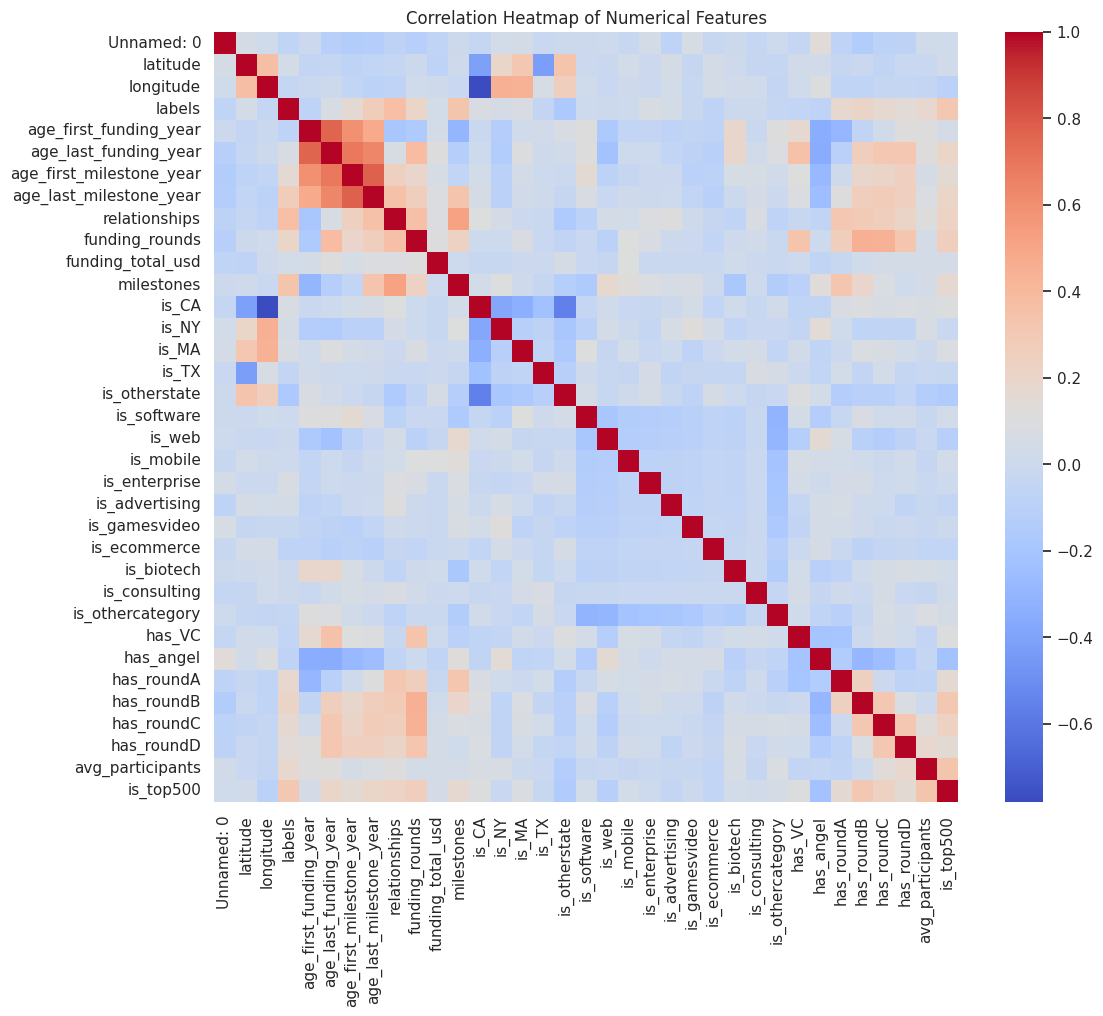

In [8]:
# Correlation Heatmap (Numerical Features Only)

# Selecting only numeric columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(12,10))
sns.heatmap(numeric_df.corr(), annot=False, cmap='coolwarm')
plt.title("Correlation Heatmap of Numerical Features")
plt.show()


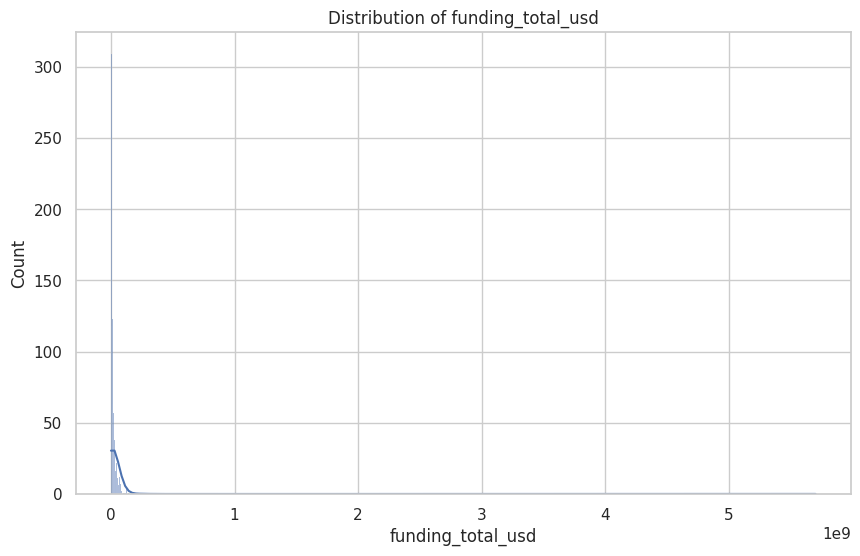

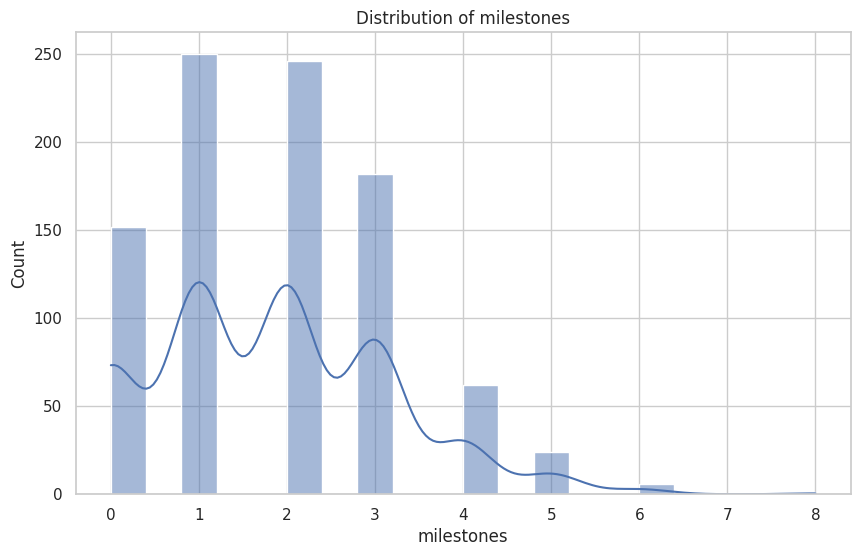

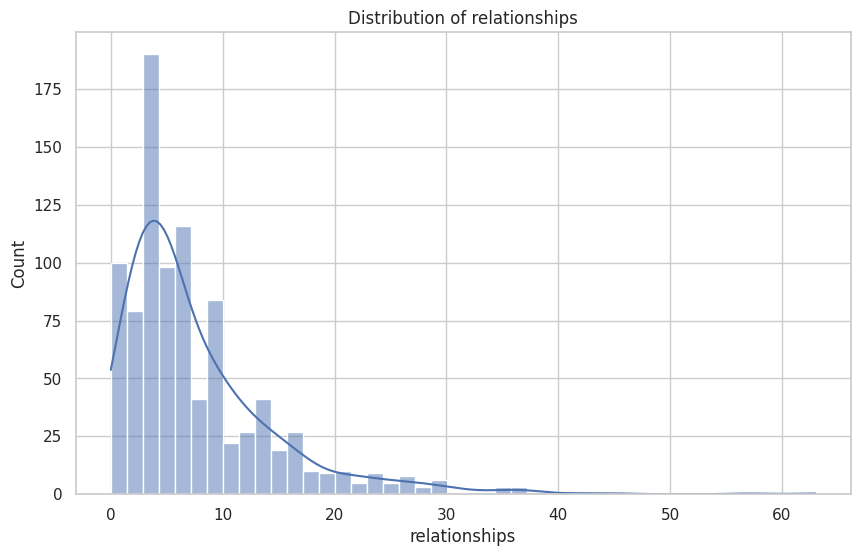

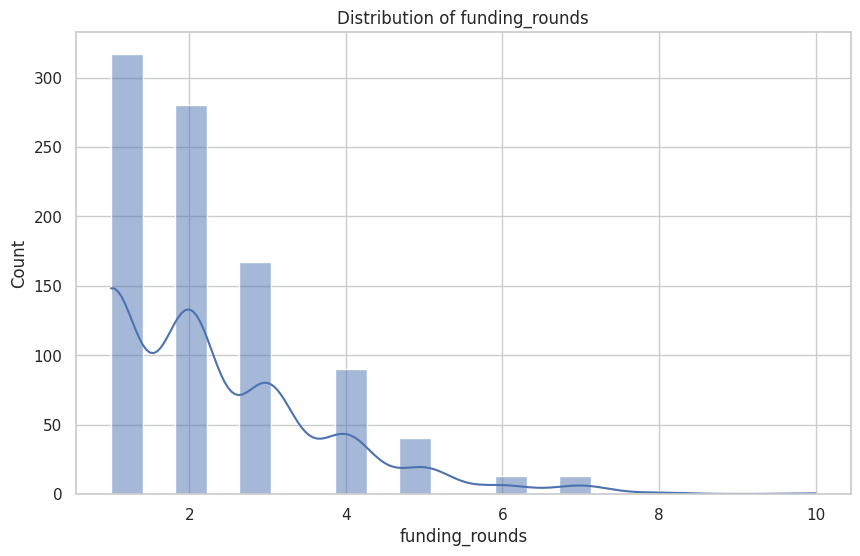

In [9]:
# Distribution Plots for Important Numerical Features

important_features = ['funding_total_usd', 'milestones', 'relationships', 'funding_rounds']

for feature in important_features:
    if feature in df.columns:
        plt.figure()
        sns.histplot(df[feature], kde=True)
        plt.title(f"Distribution of {feature}")
        plt.show()


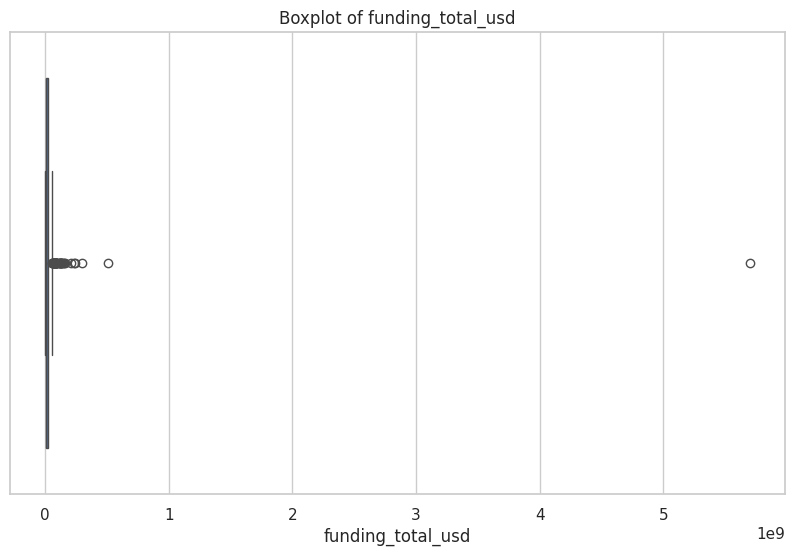

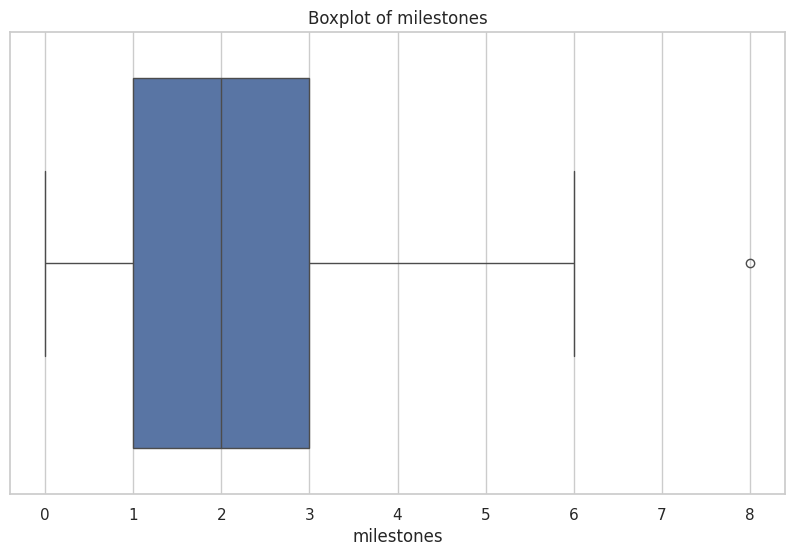

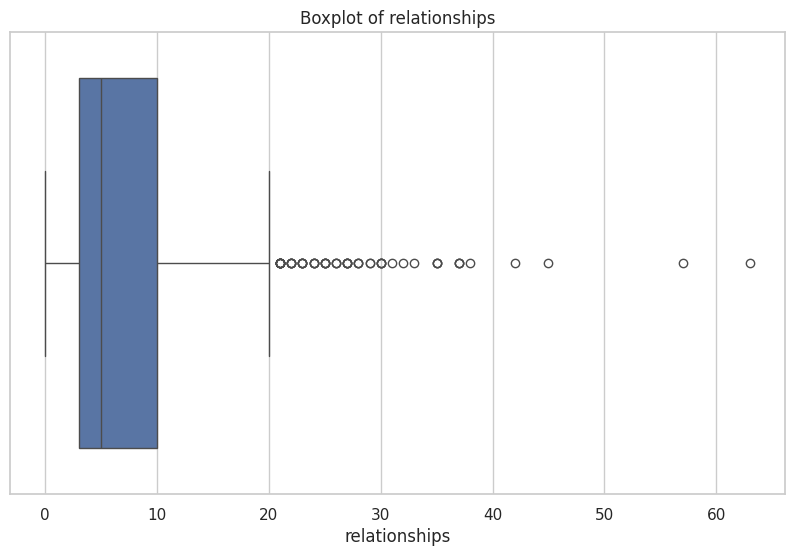

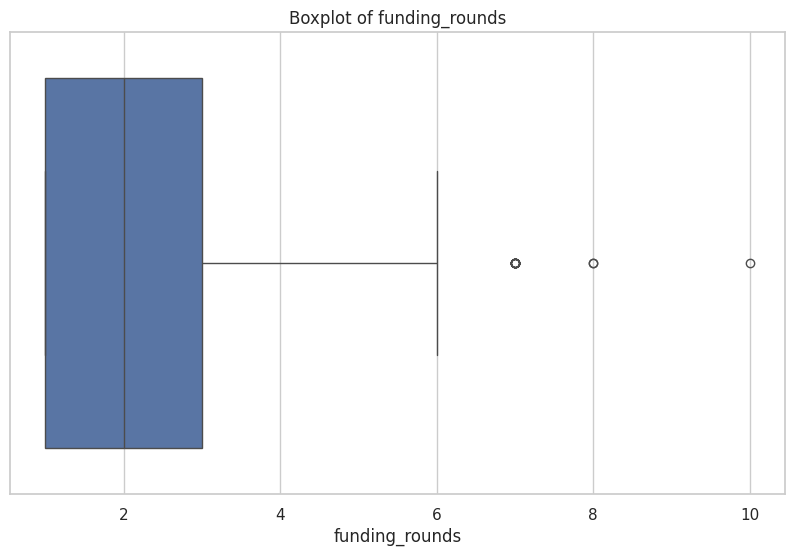

In [10]:
# Boxplot for Outlier Detection

for feature in important_features:
    if feature in df.columns:
        plt.figure()
        sns.boxplot(x=df[feature])
        plt.title(f"Boxplot of {feature}")
        plt.show()


In [11]:
df.isnull().sum()

,0
Unnamed: 0,0
state_code,0
latitude,0
longitude,0
zip_code,0
id,0
city,0
Unnamed: 6,493
name,0
labels,0


In [12]:
df.describe()


,Unnamed: 0,latitude,longitude,labels,age_first_funding_year,age_last_funding_year,age_first_milestone_year,age_last_milestone_year,relationships,funding_rounds,...,is_consulting,is_othercategory,has_VC,has_angel,has_roundA,has_roundB,has_roundC,has_roundD,avg_participants,is_top500
count,923.000000,923.000000,923.000000,923.000000,923.000000,923.000000,771.000000,771.000000,923.000000,923.000000,...,923.000000,923.000000,923.000000,923.000000,923.000000,923.000000,923.000000,923.000000,923.000000,923.000000
mean,572.297941,38.517442,-103.539212,0.646804,2.235630,3.931456,3.055353,4.754423,7.710726,2.310943,...,0.003250,0.322860,0.326111,0.254605,0.508126,0.392199,0.232936,0.099675,2.838586,0.809317
std,333.585431,3.741497,22.394167,0.478222,2.510449,2.967910,2.977057,3.212107,7.265776,1.390922,...,0.056949,0.467823,0.469042,0.435875,0.500205,0.488505,0.422931,0.299729,1.874601,0.393052
min,1.000000,25.752358,-122.756956,0.000000,-9.046600,-9.046600,-14.169900,-7.005500,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,283.500000,37.388869,-122.198732,0.000000,0.576700,1.669850,1.000000,2.411000,3.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.500000,1.000000
50%,577.000000,37.779281,-118.374037,1.000000,1.446600,3.528800,2.520500,4.476700,5.000000,2.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,2.500000,1.000000
75%,866.500000,40.730646,-77.214731,1.000000,3.575350,5.560250,4.686300,6.753400,10.000000,3.000000,...,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,3.800000,1.000000
max,1153.000000,59.335232,18.057121,1.000000,21.895900,21.895900,24.684900,24.684900,63.000000,10.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,16.000000,1.000000


In [13]:
# List of columns to drop
drop_cols = [
    'Unnamed: 0',
    'Unnamed: 6',
    'id',
    'object_id',
    'name',
    'zip_code',
    'city',
    'state_code',
    'state_code.1'
]

# Drop columns (errors='ignore' prevents crashes if a column is missing)
df = df.drop(columns=drop_cols, errors='ignore')

# Verify
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 923 entries, 0 to 922
Data columns (total 40 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   latitude                  923 non-null    float64
 1   longitude                 923 non-null    float64
 2   labels                    923 non-null    int64  
 3   founded_at                923 non-null    object 
 4   closed_at                 335 non-null    object 
 5   first_funding_at          923 non-null    object 
 6   last_funding_at           923 non-null    object 
 7   age_first_funding_year    923 non-null    float64
 8   age_last_funding_year     923 non-null    float64
 9   age_first_milestone_year  771 non-null    float64
 10  age_last_milestone_year   771 non-null    float64
 11  relationships             923 non-null    int64  
 12  funding_rounds            923 non-null    int64  
 13  funding_total_usd         923 non-null    int64  
 14  milestones

In [14]:
df = df.drop(columns=['closed_at'])
df['age_first_milestone_year'] = df['age_first_milestone_year'].fillna(
    df['age_first_milestone_year'].median()
)

df['age_last_milestone_year'] = df['age_last_milestone_year'].fillna(
    df['age_last_milestone_year'].median()
)
df.isnull().sum()


,0
latitude,0
longitude,0
labels,0
founded_at,0
first_funding_at,0
last_funding_at,0
age_first_funding_year,0
age_last_funding_year,0
age_first_milestone_year,0
age_last_milestone_year,0


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 923 entries, 0 to 922
Data columns (total 39 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   latitude                  923 non-null    float64
 1   longitude                 923 non-null    float64
 2   labels                    923 non-null    int64  
 3   founded_at                923 non-null    object 
 4   first_funding_at          923 non-null    object 
 5   last_funding_at           923 non-null    object 
 6   age_first_funding_year    923 non-null    float64
 7   age_last_funding_year     923 non-null    float64
 8   age_first_milestone_year  923 non-null    float64
 9   age_last_milestone_year   923 non-null    float64
 10  relationships             923 non-null    int64  
 11  funding_rounds            923 non-null    int64  
 12  funding_total_usd         923 non-null    int64  
 13  milestones                923 non-null    int64  
 14  is_CA     

In [ ]:
df.isnull().sum()

,0
latitude,0
longitude,0
labels,0
founded_at,0
first_funding_at,0
last_funding_at,0
age_first_funding_year,0
age_last_funding_year,0
age_first_milestone_year,0
age_last_milestone_year,0


In [ ]:
df.describe()

,latitude,longitude,labels,age_first_funding_year,age_last_funding_year,age_first_milestone_year,age_last_milestone_year,relationships,funding_rounds,funding_total_usd,...,is_consulting,is_othercategory,has_VC,has_angel,has_roundA,has_roundB,has_roundC,has_roundD,avg_participants,is_top500
count,923.000000,923.000000,923.000000,923.000000,923.000000,923.000000,923.000000,923.000000,923.000000,9.230000e+02,...,923.000000,923.000000,923.000000,923.000000,923.000000,923.000000,923.000000,923.000000,923.000000,923.000000
mean,38.517442,-103.539212,0.646804,2.235630,3.931456,2.967273,4.708687,7.710726,2.310943,2.541975e+07,...,0.003250,0.322860,0.326111,0.254605,0.508126,0.392199,0.232936,0.099675,2.838586,0.809317
std,3.741497,22.394167,0.478222,2.510449,2.967910,2.727845,2.937226,7.265776,1.390922,1.896344e+08,...,0.056949,0.467823,0.469042,0.435875,0.500205,0.488505,0.422931,0.299729,1.874601,0.393052
min,25.752358,-122.756956,0.000000,-9.046600,-9.046600,-14.169900,-7.005500,0.000000,1.000000,1.100000e+04,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,37.388869,-122.198732,0.000000,0.576700,1.669850,1.252100,2.930150,3.000000,1.000000,2.725000e+06,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.500000,1.000000
50%,37.779281,-118.374037,1.000000,1.446600,3.528800,2.520500,4.476700,5.000000,2.000000,1.000000e+07,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,2.500000,1.000000
75%,40.730646,-77.214731,1.000000,3.575350,5.560250,4.002700,6.039750,10.000000,3.000000,2.472500e+07,...,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,3.800000,1.000000
max,59.335232,18.057121,1.000000,21.895900,21.895900,24.684900,24.684900,63.000000,10.000000,5.700000e+09,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,16.000000,1.000000


In [15]:
# Drop status, keep labels as target
df = df.drop(columns=['status'])

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 923 entries, 0 to 922
Data columns (total 38 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   latitude                  923 non-null    float64
 1   longitude                 923 non-null    float64
 2   labels                    923 non-null    int64  
 3   founded_at                923 non-null    object 
 4   first_funding_at          923 non-null    object 
 5   last_funding_at           923 non-null    object 
 6   age_first_funding_year    923 non-null    float64
 7   age_last_funding_year     923 non-null    float64
 8   age_first_milestone_year  923 non-null    float64
 9   age_last_milestone_year   923 non-null    float64
 10  relationships             923 non-null    int64  
 11  funding_rounds            923 non-null    int64  
 12  funding_total_usd         923 non-null    int64  
 13  milestones                923 non-null    int64  
 14  is_CA     

In [16]:
# STEP 1: Convert date columns to datetime
df['founded_at'] = pd.to_datetime(df['founded_at'], errors='coerce')
df['first_funding_at'] = pd.to_datetime(df['first_funding_at'], errors='coerce')
df['last_funding_at'] = pd.to_datetime(df['last_funding_at'], errors='coerce')

# STEP 2: Extract year from date columns
df['founded_year'] = df['founded_at'].dt.year
df['first_funding_year'] = df['first_funding_at'].dt.year
df['last_funding_year'] = df['last_funding_at'].dt.year

# Fill missing years with median
df['founded_year'] = df['founded_year'].fillna(df['founded_year'].median())
df['first_funding_year'] = df['first_funding_year'].fillna(df['first_funding_year'].median())
df['last_funding_year'] = df['last_funding_year'].fillna(df['last_funding_year'].median())

# Drop original date columns
df = df.drop(columns=['founded_at', 'first_funding_at', 'last_funding_at'])

# STEP 3: One-hot encode category_code
df = pd.get_dummies(df, columns=['category_code'], drop_first=True)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 923 entries, 0 to 922
Data columns (total 71 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   latitude                        923 non-null    float64
 1   longitude                       923 non-null    float64
 2   labels                          923 non-null    int64  
 3   age_first_funding_year          923 non-null    float64
 4   age_last_funding_year           923 non-null    float64
 5   age_first_milestone_year        923 non-null    float64
 6   age_last_milestone_year         923 non-null    float64
 7   relationships                   923 non-null    int64  
 8   funding_rounds                  923 non-null    int64  
 9   funding_total_usd               923 non-null    int64  
 10  milestones                      923 non-null    int64  
 11  is_CA                           923 non-null    int64  
 12  is_NY                           923 

In [17]:
# Separate features and target
X = df.drop('labels', axis=1)
y = df['labels']

# Train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=92,
    stratify=y
)


In [18]:
# Scaling the features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [19]:
# Train Random Forest model
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=92
)

rf_model.fit(X_train_scaled, y_train)


RandomForestClassifier(random_state=92)

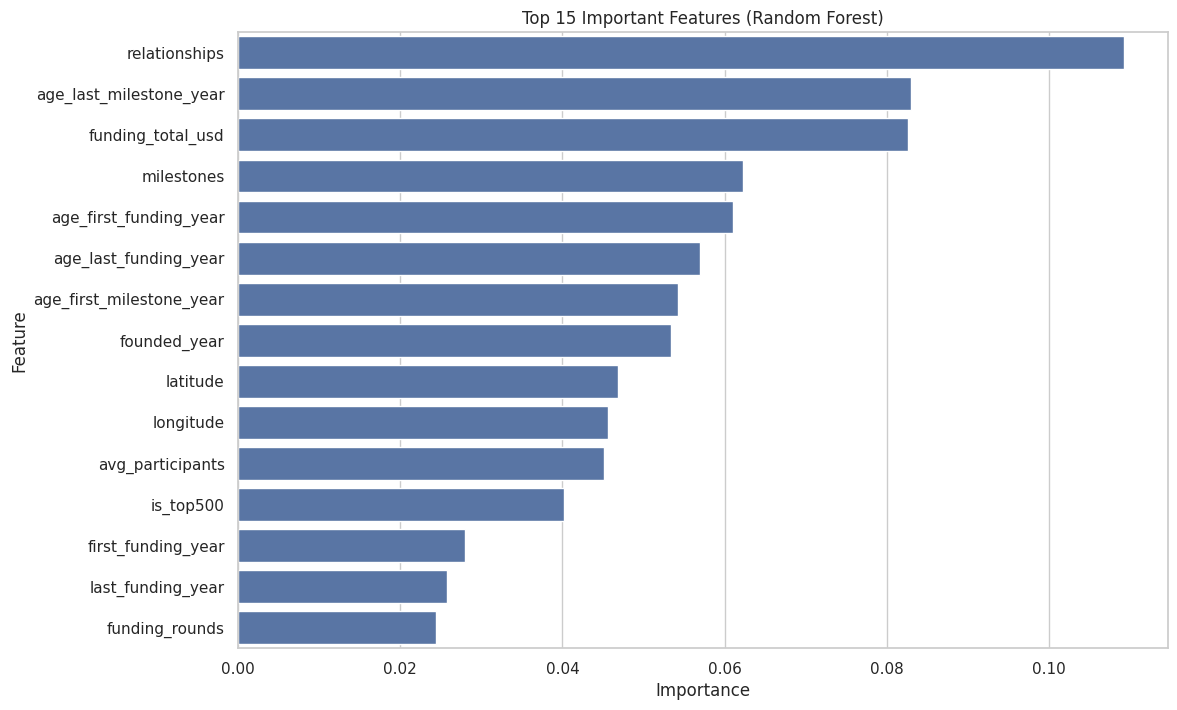

In [20]:
# Feature Importance Plot

importances = rf_model.feature_importances_
feature_names = X.columns  # Use original feature names

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12,8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(15))
plt.title("Top 15 Important Features (Random Forest)")
plt.show()


In [21]:
# Predictions
y_train_pred = rf_model.predict(X_train_scaled)
y_test_pred = rf_model.predict(X_test_scaled)


In [22]:
# Evaluation
from sklearn.metrics import accuracy_score, classification_report

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, y_test_pred))


Training Accuracy: 1.0
Testing Accuracy: 0.7621621621621621

Classification Report:

              precision    recall  f1-score   support

           0       0.68      0.60      0.64        65
           1       0.80      0.85      0.82       120

    accuracy                           0.76       185
   macro avg       0.74      0.72      0.73       185
weighted avg       0.76      0.76      0.76       185



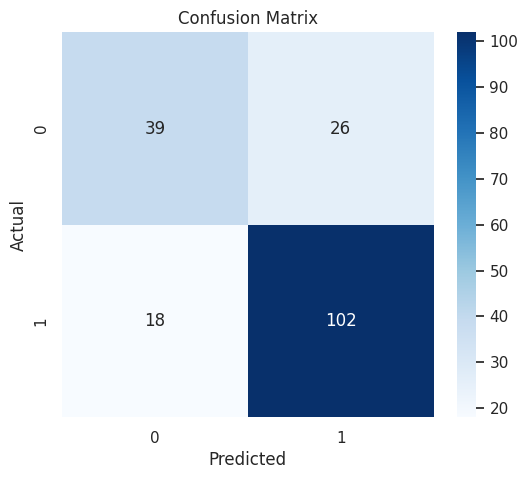

In [23]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


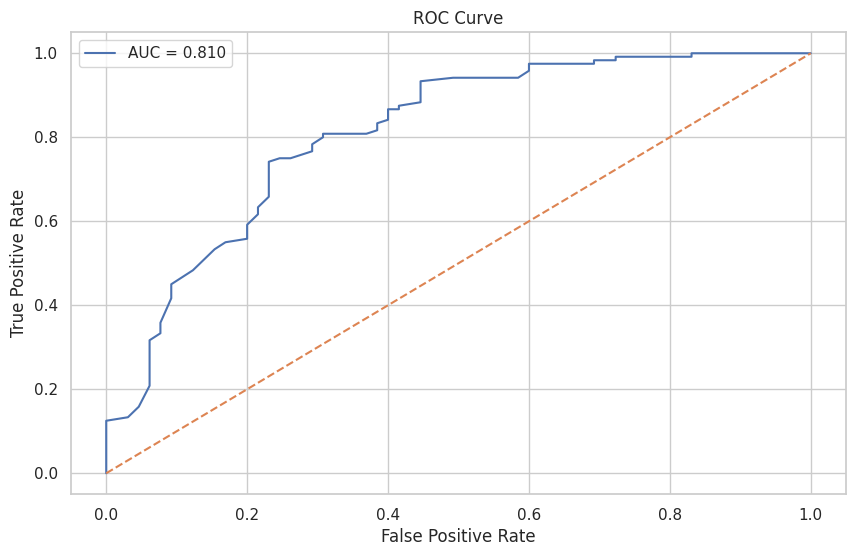

AUC Score: 0.8097435897435897


In [24]:
from sklearn.metrics import roc_curve, roc_auc_score

# Get prediction probabilities
y_test_proba = rf_model.predict_proba(X_test_scaled)[:,1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)

# Calculate AUC score
auc_score = roc_auc_score(y_test, y_test_proba)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print("AUC Score:", auc_score)


In [25]:
import joblib

# Save trained Random Forest model
joblib.dump(rf_model, 'random_forest_model.pkl')
# Save the scaler
joblib.dump(scaler, 'scaler.pkl')
# Save feature order
feature_columns = X.columns.tolist()

joblib.dump(feature_columns, 'feature_columns.pkl')


['feature_columns.pkl']

In [26]:
# Load and verify
loaded_model = joblib.load('random_forest_model.pkl')
loaded_scaler = joblib.load('scaler.pkl')
loaded_features = joblib.load('feature_columns.pkl')

print(len(loaded_features))


70


In [ ]:
print("Session active")



Session active


In [ ]:
df.to_csv("cleaned_dataset.csv", index=False)


In [ ]:
print(X.shape)
print(X.columns[:10])
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


(923, 70)
Index(['latitude', 'longitude', 'age_first_funding_year',
       'age_last_funding_year', 'age_first_milestone_year',
       'age_last_milestone_year', 'relationships', 'funding_rounds',
       'funding_total_usd', 'milestones'],
      dtype='object')
Train shape: (738, 70)
Test shape: (185, 70)


In [ ]:
print("Number of Features:", len(X.columns))
print("\nFeature List:\n")
print(X.columns.tolist())


Number of Features: 70

Feature List:

['latitude', 'longitude', 'age_first_funding_year', 'age_last_funding_year', 'age_first_milestone_year', 'age_last_milestone_year', 'relationships', 'funding_rounds', 'funding_total_usd', 'milestones', 'is_CA', 'is_NY', 'is_MA', 'is_TX', 'is_otherstate', 'is_software', 'is_web', 'is_mobile', 'is_enterprise', 'is_advertising', 'is_gamesvideo', 'is_ecommerce', 'is_biotech', 'is_consulting', 'is_othercategory', 'has_VC', 'has_angel', 'has_roundA', 'has_roundB', 'has_roundC', 'has_roundD', 'avg_participants', 'is_top500', 'founded_year', 'first_funding_year', 'last_funding_year', 'category_code_analytics', 'category_code_automotive', 'category_code_biotech', 'category_code_cleantech', 'category_code_consulting', 'category_code_ecommerce', 'category_code_education', 'category_code_enterprise', 'category_code_fashion', 'category_code_finance', 'category_code_games_video', 'category_code_hardware', 'category_code_health', 'category_code_hospitality', 'ca

In [ ]:
print("Shape of X_train_scaled:", X_train_scaled.shape)


Shape of X_train_scaled: (738, 70)


In [ ]:
print("Model expects:", rf_model.n_features_in_, "features")

Model expects: 70 features


In [ ]:
loaded_features = joblib.load("feature_columns.pkl")
print(len(loaded_features))
print(loaded_features)


70
['latitude', 'longitude', 'age_first_funding_year', 'age_last_funding_year', 'age_first_milestone_year', 'age_last_milestone_year', 'relationships', 'funding_rounds', 'funding_total_usd', 'milestones', 'is_CA', 'is_NY', 'is_MA', 'is_TX', 'is_otherstate', 'is_software', 'is_web', 'is_mobile', 'is_enterprise', 'is_advertising', 'is_gamesvideo', 'is_ecommerce', 'is_biotech', 'is_consulting', 'is_othercategory', 'has_VC', 'has_angel', 'has_roundA', 'has_roundB', 'has_roundC', 'has_roundD', 'avg_participants', 'is_top500', 'founded_year', 'first_funding_year', 'last_funding_year', 'category_code_analytics', 'category_code_automotive', 'category_code_biotech', 'category_code_cleantech', 'category_code_consulting', 'category_code_ecommerce', 'category_code_education', 'category_code_enterprise', 'category_code_fashion', 'category_code_finance', 'category_code_games_video', 'category_code_hardware', 'category_code_health', 'category_code_hospitality', 'category_code_manufacturing', 'categor